In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# Import Regression Models (Assuming we are predicting continuous quality)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [42]:
df = pd.read_csv("Wine Quality Dataset.csv")

In [43]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free sulfur dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total sulfur dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


In [45]:
df.isnull().sum()           # count per column
df.isnull().mean() * 100    # % missing per column

fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

In [46]:
# How to handle each case:
# Case 1: Drop rows — only when < 5% missing AND MCAR
df.dropna(subset=['pH'], inplace=True)

# Case 2: Fill with median (skewed numeric columns)
df['residual sugar'].fillna(df['residual sugar'].median(), inplace=True)

# Case 3: Fill with mean (normally distributed)
df['alcohol'].fillna(df['alcohol'].mean(), inplace=True)

df.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_3936\1965937340.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['residual sugar'].fillna(df['residual sugar'].median(), inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_3936\1965937340.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series throug

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [47]:

numeric_cols = df.select_dtypes(include=np.number).columns

print(numeric_cols)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')


In [48]:
# Method 1: IQR (Interquartile Range) — most common
Q1 = df['alcohol'].quantile(0.25)
Q3 = df['alcohol'].quantile(0.75)
IQR = Q3 - Q1

print(IQR)
print(Q3)
print(Q1)

1.9000000000000004
11.4
9.5


In [49]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['alcohol'] < lower) | (df['alcohol'] > upper)]
print(f"Outliers found: {len(outliers)}")


Outliers found: 0


In [50]:
# Step 5 — handle outliers (IQR method)
for col in ['alcohol', 'residual sugar', 'total sulfur dioxide']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

In [51]:
print(df.isnull().sum().sum(), "missing values remaining")
print(df.shape, "final shape")

0 missing values remaining
(4898, 12) final shape


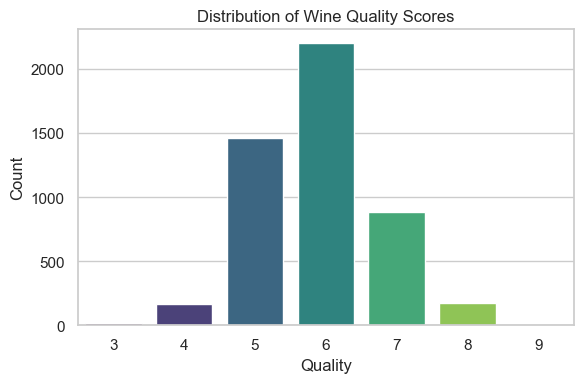

In [52]:
# Set default styling for aesthetics
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='quality', hue='quality', palette='viridis', legend=False)
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

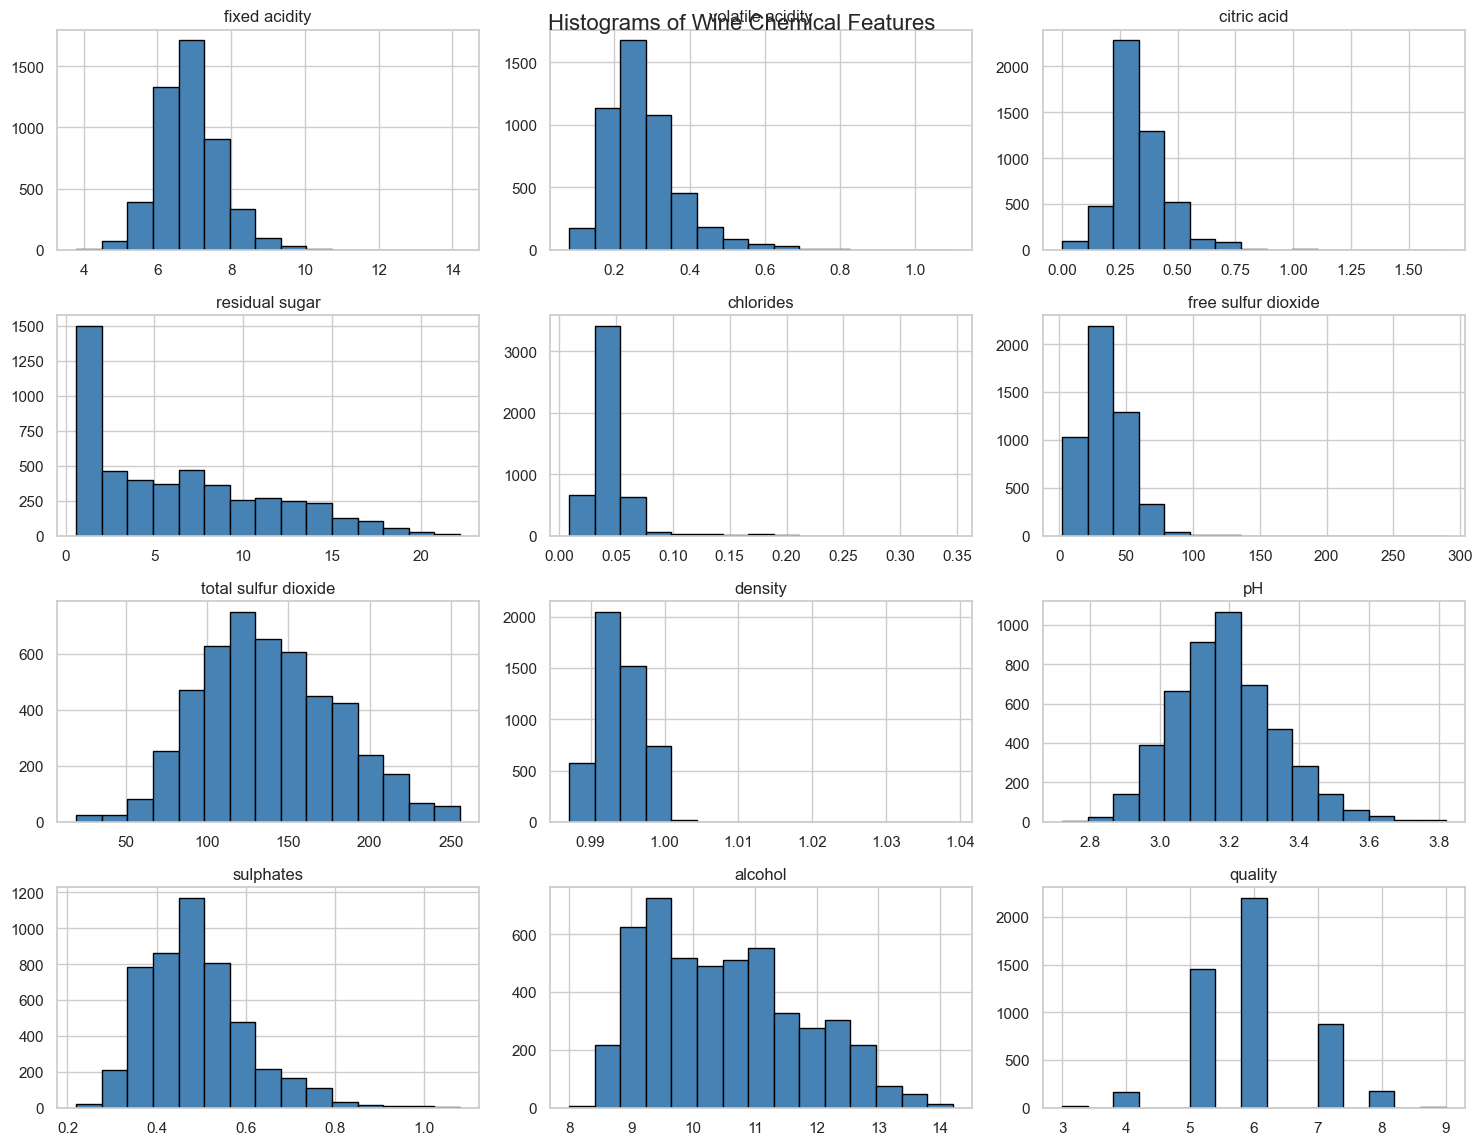

In [53]:
# 3.2 Univariate Feature Distributions (Histograms)
# Helps observe skewness and underlying patterns of chemical properties
df.hist(bins=15, figsize=(15, 12), layout=(4, 3), edgecolor='black', color='steelblue')
plt.suptitle('Histograms of Wine Chemical Features', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

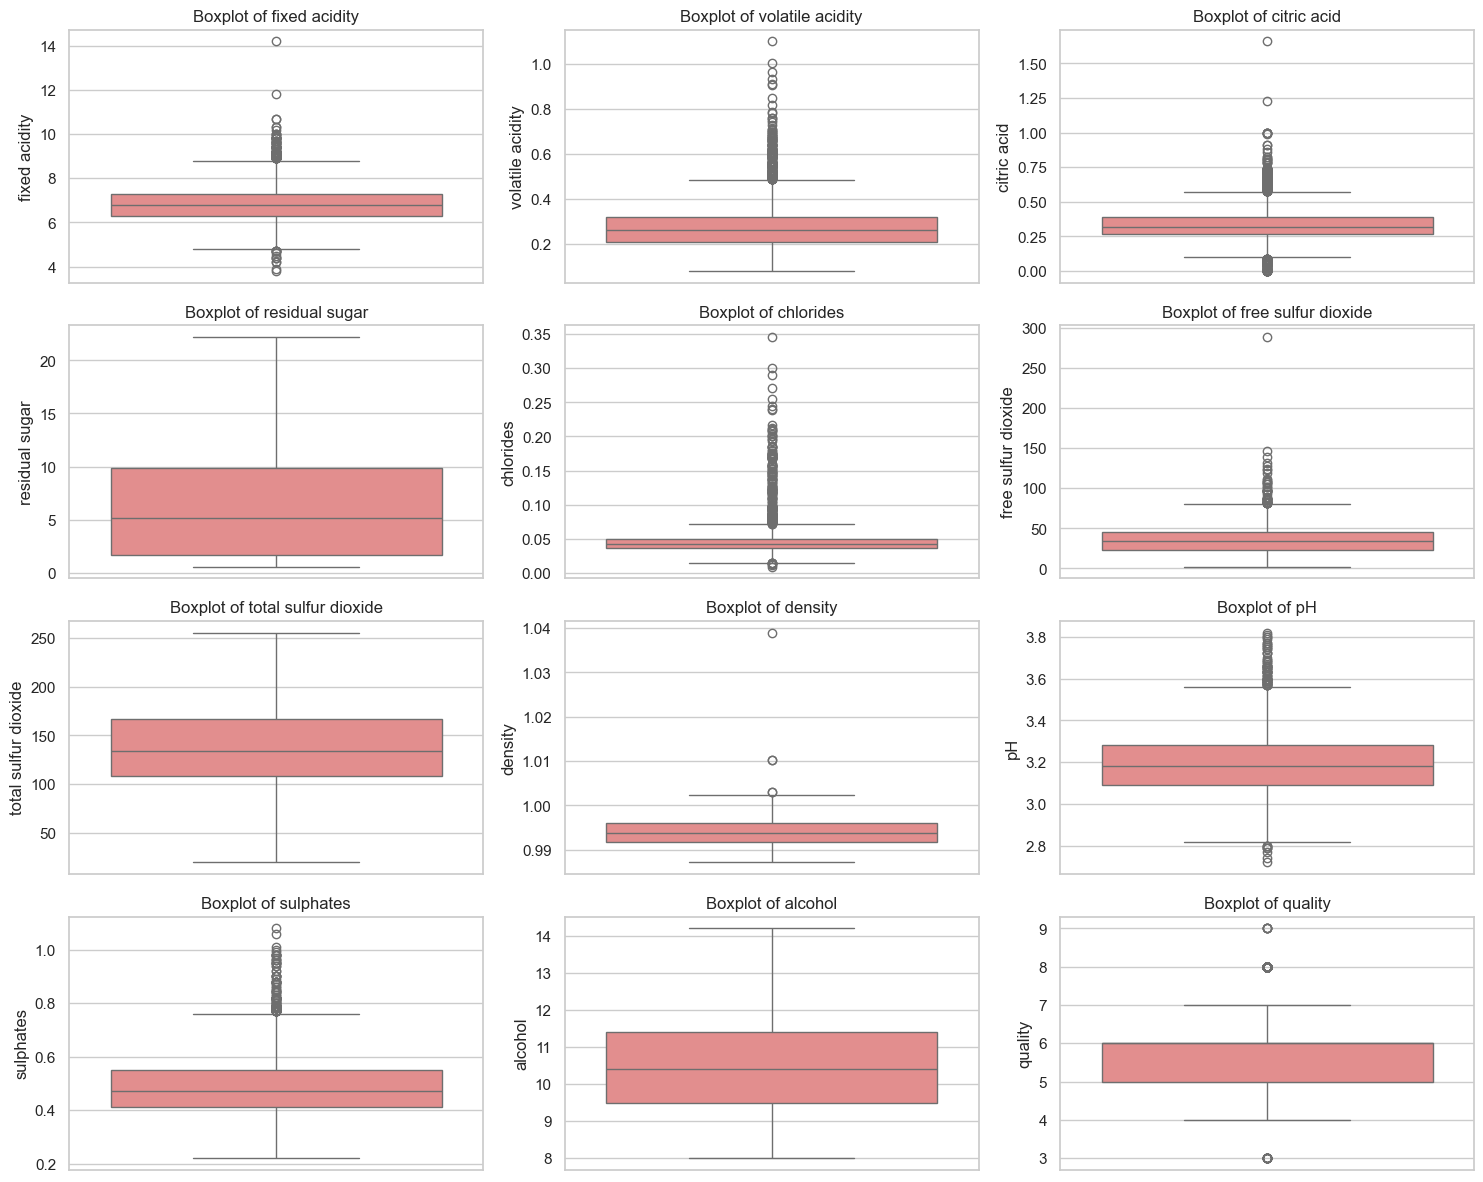

In [54]:
# 3.3 Outlier Detection (Boxplots)
# Useful for finding data points that vary significantly from others
plt.figure(figsize=(15, 12))
for i, col in enumerate(df.columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=df, y=col, color='lightcoral')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

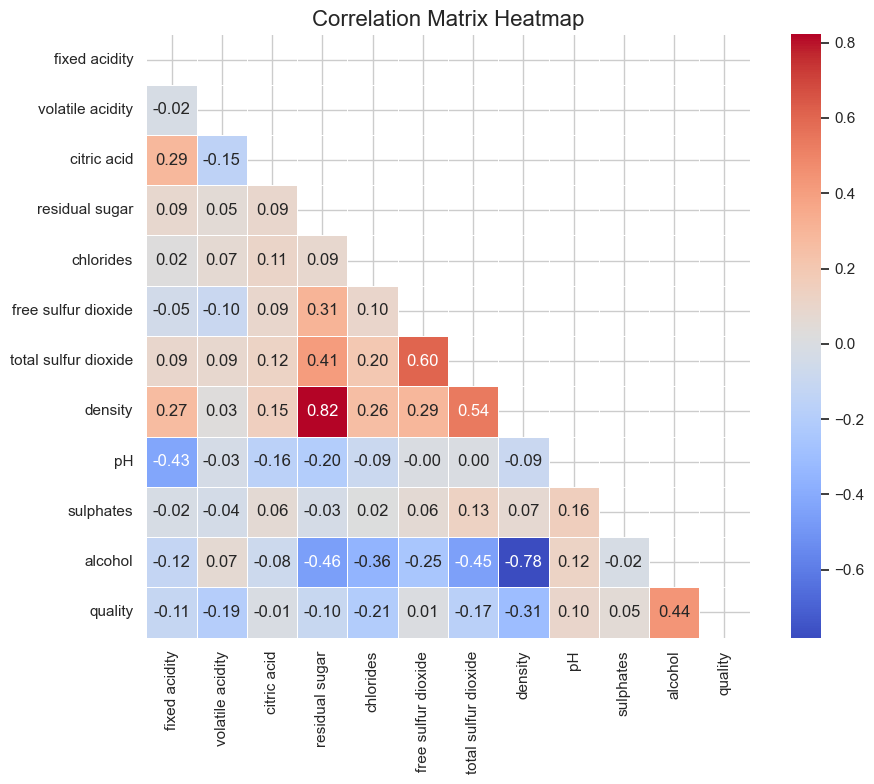

In [55]:
# 3.4 Feature Correlations (Heatmap)
# Identifies multicollinearity and strongest predictors of target variable
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

# Masking the upper triangle for cleaner presentation
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_3936\1170915766.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality', y='alcohol', palette='Set2')


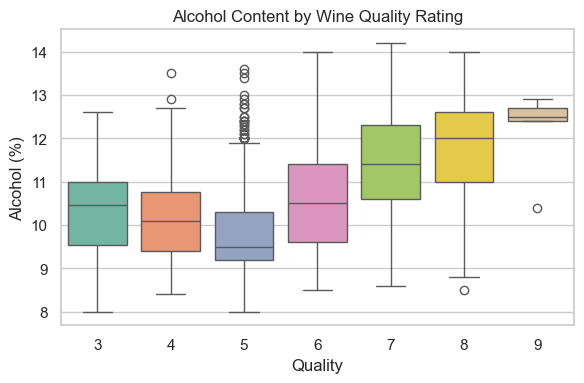

In [56]:
# 3.5 Bivariate Analysis Example (e.g., Alcohol content vs Quality)
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='quality', y='alcohol', palette='Set2')
plt.title('Alcohol Content by Wine Quality Rating')
plt.xlabel('Quality')
plt.ylabel('Alcohol (%)')
plt.tight_layout()
plt.show()

In [57]:
df.duplicated().sum()

np.int64(937)

In [58]:
df.drop_duplicates(inplace=True)

In [59]:
corr = df.corr()

quality_corr = corr['quality'].sort_values(
    ascending=False
)

print(quality_corr)

quality                 1.000000
alcohol                 0.462869
pH                      0.123829
sulphates               0.053200
free sulfur dioxide     0.010507
citric acid             0.007065
residual sugar         -0.120277
fixed acidity          -0.124636
total sulfur dioxide   -0.178316
volatile acidity       -0.190678
chlorides              -0.217739
density                -0.337805
Name: quality, dtype: float64


In [60]:
selected_features = [
    'alcohol',
    'density',
    'volatile acidity',
    'chlorides',
    'citric acid',
    'sulphates'
]

X = df[selected_features]
y = df['quality']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [62]:
# ---------------------------------------------
# Approach A: Standardization (Z-score)
# ---------------------------------------------
std_scaler = StandardScaler()
# Fit on training data and transform both
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

In [63]:
# ---------------------------------------------
# Approach B: Min-Max Scaling (Normalization)
# ---------------------------------------------
min_max_scaler = MinMaxScaler()

# Fit on training data and transform both
X_train_norm = min_max_scaler.fit_transform(X_train)
X_test_norm = min_max_scaler.transform(X_test)

In [64]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Support Vector Regressor': SVR(kernel='rbf'),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

In [65]:

results_list = []

print("--- Model Training & Cross-Validation ---")
for name, model in models.items():
    # Build a pipeline that scales the data first, then fits the model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])
    
    # Evaluate using Cross-Validation on training data (using Neg Mean Squared Error)
    # Note: For small dummy datasets, cv=2 or 3 is used to prevent errors.
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=2, scoring='neg_mean_squared_error')
    rmse_cv = np.sqrt(-cv_scores.mean())
    
    # Fit model on full training set
    pipeline.fit(X_train, y_train)
    
    # Predict on unseen test data
    y_pred = pipeline.predict(X_test)
    
    # Calculate performance metrics
    mse_test = mean_squared_error(y_test, y_pred)
    rmse_test = np.sqrt(mse_test)
    r2 = r2_score(y_test, y_pred)
    
    # Store metrics for comparison table
    results_list.append({
        'Model': name,
        'CV RMSE': rmse_cv,
        'Test RMSE': rmse_test,
        'Test R²': r2
    })
    print(f"Finished training: {name}")

# ==========================================
# 4. Compare Results
# ==========================================
results_df = pd.DataFrame(results_list).sort_values(by='Test RMSE')
print("\n--- Final Performance Comparison (Sorted by Test RMSE) ---")
print(results_df.to_string(index=False))

--- Model Training & Cross-Validation ---
Finished training: Linear Regression
Finished training: Ridge Regression
Finished training: Support Vector Regressor
Finished training: Random Forest
Finished training: Gradient Boosting

--- Final Performance Comparison (Sorted by Test RMSE) ---
                   Model  CV RMSE  Test RMSE  Test R²
       Gradient Boosting 0.758214   0.783308 0.251858
           Random Forest 0.766960   0.789272 0.240422
        Ridge Regression 0.757645   0.794000 0.231294
       Linear Regression 0.757643   0.794011 0.231274
Support Vector Regressor 0.750512   0.798627 0.222309
